# 🧠🤖 第2周·Day 1 | FFN、LayerNorm 与残差连接

> **今日目标**: 理解 Transformer Block 中三大关键组件——前馈神经网络、层归一化和残差连接，搞清楚它们各自的角色和配合方式。

---

## 📝 核心知识点

### 🔹 FFN（前馈神经网络）💪
- **位置**: 紧跟在注意力层后面
- **结构**: 两层线性变换 + 激活函数（ReLU/GELU）
- **本质**: 给每个 token 做独立的"深度思考"
  - 先把向量升维（扩展到4倍），再降维回来
  - 类比：注意力层是"找关系"，FFN 是"深加工"
  - 每个 token 独立处理，不跟其他 token 交互

### 🔹 LayerNorm（层归一化）⚖️
- **作用**: 稳定训练过程，防止数值爆炸
- **做法**: 把每一层的输出标准化到均值为0、方差为1
- **位置**: Transformer 里用了两次——注意力前后各一次
  - **Pre-Norm**: 先归一化再计算（现代大模型常用）
  - **Post-Norm**: 先计算再归一化（原始 Transformer 设计）
  - 类比：给每层输出做"血压检测"，防止数值偏离太远

### 🔹 残差连接（Residual Connection）🔗
- **做法**: 把层的输入直接加到输出上 `output = f(x) + x`
- **作用**: 让梯度可以"抄近路"回传，解决深层网络训练难题
  - 没有残差连接，100层的网络根本训不动
  - 有了残差连接，即使中间层没学到东西，信息也能无损传递
  - 类比：建高楼时每层都留一部直达电梯

### 🔹 三者如何配合？
信息流经过一个 Transformer 块：
```
输入 → LayerNorm → Multi-Head Attention → (+残差) → LayerNorm → FFN → (+残差) → 输出
```
- LayerNorm 保证稳定
- 注意力层抓关系
- FFN 做变换
- 残差连接保底传递信息

## 💻 代码演示：FFN 前馈神经网络

用代码演示 FFN 的"升维→激活→降维"过程：

In [11]:
import numpy as np

np.random.seed(42)

# 模拟: 3个词，每个词8维向量
seq_len, d_model = 3, 8
d_ff = d_model * 4  # FFN隐藏层维度 = 4倍

X = np.random.randn(seq_len, d_model)

# FFN的两层权重
W1 = np.random.randn(d_model, d_ff)
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff, d_model)
b2 = np.zeros(d_model)

print(f"输入 shape: {X.shape}")
print(f"隐藏层维度: {d_ff} (是输入的4倍)")
print(f"输出 shape 将回到: ({seq_len}, {d_model})")

输入 shape: (3, 8)
隐藏层维度: 32 (是输入的4倍)
输出 shape 将回到: (3, 8)


In [12]:
# FFN 前向传播: 升维 → GELU激活 → 降维

def gelu(x):
    """GELU 激活函数（现代大模型常用）"""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def relu(x):
    """ReLU 激活函数（经典选择）"""
    return np.maximum(0, x)

# Step 1: 升维 (8 → 32)
hidden = X @ W1 + b1
print(f"升维后 shape: {hidden.shape}")

# Step 2: 激活函数
activated = gelu(hidden)

# Step 3: 降维 (32 → 8)
output = activated @ W2 + b2
print(f"降维后 shape: {output.shape}")

print(f"\n💡 FFN 对每个 token 独立处理，不跨 token 交互")
print(f"💡 参数量: W1({d_model}x{d_ff}) + W2({d_ff}x{d_model}) = {d_model*d_ff + d_ff*d_model}")
print(f"💡 而注意力层参数量通常只有 {d_model*d_model*3}（Q/K/V三个矩阵）")
print(f"💡 所以 FFN 参数量占 Transformer Block 的约 2/3！")

升维后 shape: (3, 32)
降维后 shape: (3, 8)

💡 FFN 对每个 token 独立处理，不跨 token 交互
💡 参数量: W1(8x32) + W2(32x8) = 512
💡 而注意力层参数量通常只有 192（Q/K/V三个矩阵）
💡 所以 FFN 参数量占 Transformer Block 的约 2/3！


## 💻 代码演示：LayerNorm 层归一化

看看 LayerNorm 如何把数值"拉回正常范围"：

In [13]:
# LayerNorm: 标准化到均值为0、方差为1

def layer_norm(x, eps=1e-5):
    """对每个样本独立做归一化"""
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    x_norm = (x - mean) / np.sqrt(var + eps)
    # gamma 和 beta 是可学习参数（每个特征维度独立缩放/偏移）
    gamma = np.ones(x.shape[-1])  # shape: (d_model,)
    beta = np.zeros(x.shape[-1])  # shape: (d_model,)
    return gamma * x_norm + beta

# 模拟一个数值范围很大的输入
x_raw = np.array([[100.0, -50.0, 0.01, 200.0, -150.0, 75.0, -80.0, 120.0]])
print("原始值:", np.round(x_raw, 2))
print(f"  均值: {x_raw.mean():.2f}, 标准差: {x_raw.std():.2f}")

x_normed = layer_norm(x_raw)
print("\nLayerNorm 后:", np.round(x_normed, 4))
print(f"  均值: {x_normed.mean():.6f}, 标准差: {x_normed.std():.4f}")

print("\n💡 LayerNorm 把数值「压缩」到稳定范围，防止深层网络数值爆炸")


原始值: [[ 1.0e+02 -5.0e+01  1.0e-02  2.0e+02 -1.5e+02  7.5e+01 -8.0e+01  1.2e+02]]
  均值: 26.88, 标准差: 109.34

LayerNorm 后: [[ 0.6688 -0.7031 -0.2457  1.5833 -1.6176  0.4401 -0.9774  0.8517]]
  均值: 0.000000, 标准差: 1.0000

💡 LayerNorm 把数值「压缩」到稳定范围，防止深层网络数值爆炸


## 💻 代码演示：残差连接

对比有/无残差连接时，信息能否"穿过"网络：

In [14]:
# 残差连接: output = f(x) + x

np.random.seed(42)
x = np.array([[1.0, 2.0, 3.0, 4.0]])  # 原始输入

# 模拟一个还没训练好的层（随机权重，输出和输入无关）
W = np.random.randn(4, 4) * 0.01  # 很小的随机权重
f_x = x @ W

# 无残差连接
no_residual = f_x

# 有残差连接
with_residual = f_x + x

print("原始输入:", x[0])
print("层输出 f(x):", np.round(f_x[0], 4))
print("\n无残差连接:", np.round(no_residual[0], 4), "← 原始信息丢失！")
print("有残差连接:", np.round(with_residual[0], 4), "← 原始信息保留！")

print("\n💡 即使这一层什么都没学到，残差连接也能把原始信息原封不动传下去")
print("💡 这就是为什么 Transformer 能堆叠 100 层还训得动")

原始输入: [1. 2. 3. 4.]
层输出 f(x): [-0.0041 -0.0663 -0.0448 -0.0059]

无残差连接: [-0.0041 -0.0663 -0.0448 -0.0059] ← 原始信息丢失！
有残差连接: [0.9959 1.9337 2.9552 3.9941] ← 原始信息保留！

💡 即使这一层什么都没学到，残差连接也能把原始信息原封不动传下去
💡 这就是为什么 Transformer 能堆叠 100 层还训得动


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
/tmp/ipy

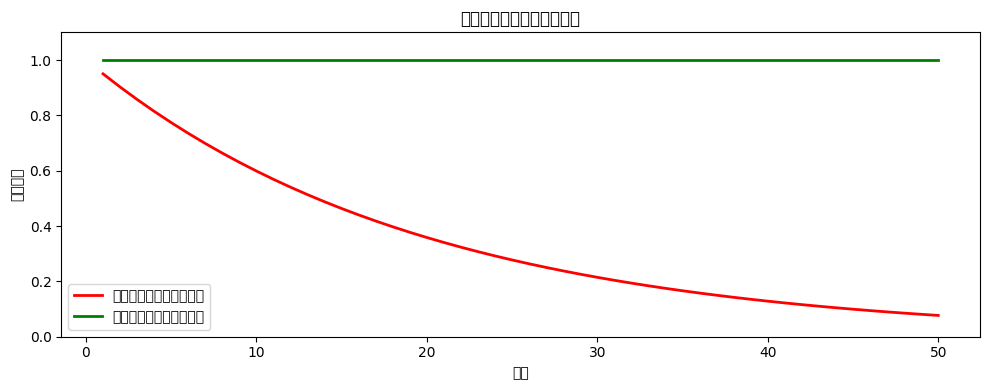

💡 红线: 50层后梯度几乎为0，网络学不到东西
💡 绿线: 无论多深，梯度都能通过残差「高速公路」回传


In [8]:
# 可视化: 多层网络中，残差连接如何保护梯度
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

layers = np.arange(1, 51)

# 模拟梯度流（无残差: 指数衰减, 有残差: 梯度至少为1）
grad_no_residual = 0.95 ** layers  # 每层衰减5%
grad_with_residual = np.ones_like(layers, dtype=float)  # 残差保证梯度至少=1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, grad_no_residual, 'r-', label='无残差连接（梯度消失）', linewidth=2)
ax.plot(layers, grad_with_residual, 'g-', label='有残差连接（梯度稳定）', linewidth=2)
ax.set_xlabel('层数')
ax.set_ylabel('梯度大小')
ax.set_title('残差连接对梯度传播的影响')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("💡 红线: 50层后梯度几乎为0，网络学不到东西")
print("💡 绿线: 无论多深，梯度都能通过残差「高速公路」回传")

## 💻 代码演示：完整 Transformer Block

把三个组件串起来：

In [15]:
# 完整 Transformer Block（Pre-Norm 版本）

np.random.seed(42)
seq_len, d_model = 3, 8
X = np.random.randn(seq_len, d_model)

print("输入:", np.round(X, 3))

# ===== 子层1: 注意力（简化版，用线性变换模拟） =====
W_attn = np.random.randn(d_model, d_model) * 0.1

# Pre-Norm → 注意力 → 残差
x_normed = layer_norm(X)
attn_out = x_normed @ W_attn
x_after_attn = attn_out + X  # 残差连接!
print("\n注意力+残差后:", np.round(x_after_attn, 3))

# ===== 子层2: FFN =====
d_ff = d_model * 4
W1 = np.random.randn(d_model, d_ff) * 0.1
W2 = np.random.randn(d_ff, d_model) * 0.1

# Pre-Norm → FFN → 残差
x_normed2 = layer_norm(x_after_attn)
hidden = gelu(x_normed2 @ W1)
ffn_out = hidden @ W2
final_output = ffn_out + x_after_attn  # 残差连接!

print("\n最终输出:", np.round(final_output, 3))
print(f"\n输出 shape: {final_output.shape} (和输入一样!)")

print("\n✅ 完整流程: LayerNorm→Attn→(+x)→LayerNorm→FFN→(+x)")
print("✅ 每一步都有残差连接保底，LayerNorm 保证稳定")

输入: [[ 0.497 -0.138  0.648  1.523 -0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466  0.242 -1.913 -1.725 -0.562]
 [-1.013  0.314 -0.908 -1.412  1.466 -0.226  0.068 -1.425]]

注意力+残差后: [[ 0.552 -0.154  0.243  1.464 -0.366  0.076  1.985  0.553]
 [-0.681 -0.111  0.064 -0.828  0.098 -2.076 -2.102 -0.567]
 [-1.186  0.41  -1.026 -1.161  1.682 -0.39  -0.391 -2.039]]

最终输出: [[ 0.363 -0.156  0.201  1.343 -0.361  0.024  1.953  0.535]
 [-0.638 -0.161  0.093 -0.808  0.21  -2.043 -2.188 -0.638]
 [-1.043  0.402 -0.951 -1.104  1.587 -0.332 -0.41  -2.003]]

输出 shape: (3, 8) (和输入一样!)

✅ 完整流程: LayerNorm→Attn→(+x)→LayerNorm→FFN→(+x)
✅ 每一步都有残差连接保底，LayerNorm 保证稳定


## 🔑 英文术语

| 术语 | 音标 | 中文 |
|------|------|------|
| FFN (Feed-Forward Network) | [fiːdˈfɔːrwərd ˈnetwɜːrk] | 前馈神经网络 |
| LayerNorm | [ˈleɪər nɔːrm] | 层归一化 |
| Residual Connection | [rɪˈzɪdjuːəl kəˈnekʃn] | 残差连接 |
| GELU | [ˈdʒɛluː] | 高斯误差线性单元，激活函数 |
| Pre-Norm | [priː nɔːrm] | 预归一化，先归一化再计算 |

## 🎬 推荐视频

> ⭐ **首选**: 从零实现Transformer——FFN+残差连接+整体实现（B站）
> https://www.bilibili.com/video/BV1xr8meLE87/

> 📺 **备选**: 3Blue1Brown - Transformer 可视化讲解
> https://www.bilibili.com/video/BV1TZ421j7Ke/

📖 **延伸阅读**：
- [Transformer 细节死磕：从残差连接、LayerNorm 到 GLU 变体全解析（知乎）](https://zhuanlan.zhihu.com/p/1996512512993153744)
- [理解 Transformer 中的子层连接结构：残差与规范化的协奏（CSDN）](https://blog.csdn.net/Wei_sx/article/details/148838359)

## ✏️ 课堂练习

1. FFN 的"升维再降维"扩展了多少倍？
   - A. 2倍  B. 4倍  C. 8倍  D. 16倍

2. LayerNorm 的核心作用是？
   - A. 加速推理  B. 稳定训练防止数值爆炸  C. 压缩模型  D. 增加参数

3. 残差连接 `output = f(x) + x`，如果 f(x) 学到了东西，结果会怎样？
   - A. 等于 x  B. 在 x 基础上叠加了新变换  C. 直接跳过 f(x)  D. 报错

4. Transformer 一个 Block 里信息经过的正确顺序？
   - A. FFN→注意力→归一化  B. 注意力→FFN→残差  C. 归一化→注意力→残差→归一化→FFN→残差  D. 以上都不对

5. "注意力层找关系，FFN 做变换"，哪个更准确？
   - A. FFN 也在找关系  B. 注意力在做变换  C. 基本准确  D. 两个作用完全一样

💡 提示：FFN 对每个 token 独立处理，不跨 token 交互——这和注意力层的关键区别

## 📝 课后测试

1. 为什么 FFN 要用"先升维再降维"的结构，而不是直接做一次线性变换？
2. 如果去掉残差连接，深层 Transformer 会出现什么问题？
3. Pre-Norm 和 Post-Norm 有什么区别？为什么现代大模型倾向用 Pre-Norm？
4. 用生活类比解释 LayerNorm 的作用
5. 💡 **业务思考**: FFN 的参数量占整个 Transformer 的 2/3 以上，如果要在有限显存下优化模型，你觉得可以怎么做？

回复答案帮你批改 ✅

## 🔄 往期回顾

**第1周-Day2**: Multi-Head Attention 把注意力分成多个"头"，每个头关注不同角度的信息，最后拼接起来，让模型同时理解多种关系。

💡 **进度**: 第2周 | 当前：大模型（Transformer深入）
🔥 明天学 Tokenizer——文字是怎么变成数字的！